# ライブラリのインストール

In [24]:
!pip install somoclu

# ライブラリのインポート

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import somoclu
import pandas as pd
%matplotlib inline

# 学習データの読み込み

In [26]:
df = pd.read_csv("sports.txt", sep="\t", header=None,index_col=0)
X = df.values
Y = df.index

# SOMの設定

In [27]:
n_rows, n_columns = 5, 5
#som = somoclu.Somoclu(n_columns, n_rows)
som = somoclu.Somoclu(n_columns, n_rows, initialcodebook=np.zeros((n_rows*n_columns, X.shape[1]), dtype=np.float32))
%time som.train(X)

CPU times: user 66.7 ms, sys: 0 ns, total: 66.7 ms
Wall time: 69.9 ms


# SOMの学習後の分類結果

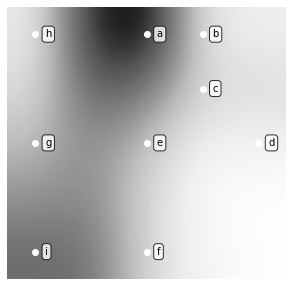

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.7/dist-packages/matplotlib/pyplot.py'>

In [28]:
som.view_umatrix(figsize =(5,5),bestmatches=True, labels=Y,colormap ='Greys')

# テストデータの読み込み

In [29]:
dft = pd.read_csv("sports_test.txt", sep="\t", header=None,index_col=0)
Xt = dft.values
Yt = dft.index

# テストデータの分類

(0, 3)
(3, 0)
[(0, 3), (3, 0)]


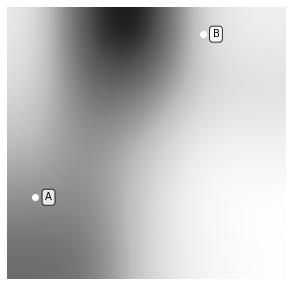

In [30]:
bum_org = som.bmus
bmus = []
for i in range(len(Xt)):
  a = np.sum((som.codebook-dft.values[i])**2,axis=2)
  idx = np.unravel_index(np.argmin(a), a.shape)
  print(idx)
  bmus.append(idx)
som.bmus = bmus
print(bmus)
som.view_umatrix(figsize =(5,5),bestmatches=True, labels=Yt,colormap ='Greys')
som.bmus = bum_org

# クラスタ分析の準備

In [31]:
from sklearn.cluster import KMeans
som.cluster(KMeans(n_clusters=2))

# SOMの各ノードのクラスタ分類の表示

In [32]:
som.clusters

array([[1, 1, 0, 0, 0],
       [1, 1, 0, 0, 0],
       [1, 1, 0, 0, 0],
       [1, 1, 0, 0, 0],
       [1, 1, 0, 0, 0]])

# 学習データのクラスの設定

In [33]:
colors =  ['r', 'b', 'g', 'k', 'c', 'm', 'y', 'grey']
a = list(map(lambda x:colors[som.clusters[som.bmus[x][1],som.bmus[x][0]]],range(len(som.bmus))))
print(a)

['r', 'r', 'r', 'r', 'r', 'r', 'b', 'b', 'b']


# 学習データのクラス分類結果の表示

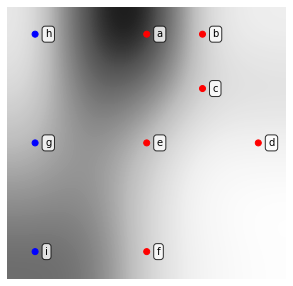

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.7/dist-packages/matplotlib/pyplot.py'>

In [34]:
som.view_umatrix(figsize =(5,5),bestmatches=True, labels=Y,colormap ='Greys', bestmatchcolors=a)

# テストデータのクラス分類結果の表示

[(0, 3), (3, 0)]
['b', 'r']


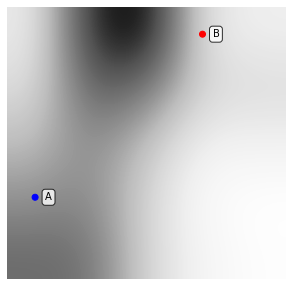

In [35]:
som.bmus = bmus
print(bmus)
colors =  ['r', 'b', 'g', 'k', 'c', 'm', 'y', 'grey']
a = list(map(lambda x:colors[som.clusters[som.bmus[x][1],som.bmus[x][0]]],range(len(som.bmus))))
print(a)
som.view_umatrix(figsize =(5,5),bestmatches=True, labels=Yt,colormap ='Greys', bestmatchcolors=a)
som.bmus = bum_org

In [36]:
som.bmus 

array([[2, 0],
       [3, 0],
       [3, 1],
       [4, 2],
       [2, 2],
       [2, 4],
       [0, 2],
       [0, 0],
       [0, 4]], dtype=int32)